# Step 3: Deep Learning — Spectrograms & CNN (Extended Training)

## Objective
We feed the **actual visual pattern of the sound wave** into a neural network. 
We convert the audio waveform into a **Mel-Spectrogram** (a 2D image of frequency and time) and train a **Convolutional Neural Network (CNN)**.

### The 5-Class Approach
We include **Frustrated** as its own distinct class alongside the standard four:
1. **Angry**
2. **Happy** (Merged with Excited)
3. **Sad**
4. **Neutral**
5. **Frustrated**

### Extended Training & Overfitting Check
In this version, we will:
1. Increase training to **30 Epochs**.
2. Track both **Train** and **Validation (Test)** performance at *every* epoch.
3. Plot the learning curves to detect **Overfitting** (when the model memorizes the training data but fails on new data).


## 0. Install Dependencies & Imports

In [7]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T

from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    
print(f"Using device: {device}")


Using device: mps


## 1. Dataset Preparation & 5-Class Mapping

In [8]:
print("Loading IEMOCAP dataset...")
ds = load_dataset("AbstractTTS/IEMOCAP", split="train")

LABEL_MAP = {
    "angry": 0, "happy": 1, "excited": 1, "sad": 2, "neutral": 3, "frustrated": 4
}
CLASS_NAMES = ["Angry", "Happy", "Sad", "Neutral", "Frustrated"]

SAMPLE_RATE = 16000
MAX_SECONDS = 4
MAX_LENGTH = SAMPLE_RATE * MAX_SECONDS

class IEMOCAPDataset(Dataset):
    def __init__(self, hf_dataset, target_sessions):
        self.data = []
        
        print(f"Preparing dataset for sessions: {target_sessions}...")
        for item in tqdm(hf_dataset):
            raw_emo = item.get("major_emotion", "")
            if raw_emo not in LABEL_MAP: continue
                
            fname = item.get("file", "")
            session_id = fname.split("/")[0] if "/" in fname else fname[:5]
            if session_id not in target_sessions: continue
                
            y = np.array(item["audio"]["array"], dtype=np.float32)
            if len(y) > MAX_LENGTH: y = y[:MAX_LENGTH]
            else: y = np.pad(y, (0, MAX_LENGTH - len(y)), "constant")
                
            self.data.append({"audio": torch.tensor(y), "label": LABEL_MAP[raw_emo]})
            
        self.melspec_transform = T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_mels=64, n_fft=1024, hop_length=512)
        self.amplitude_to_db = T.AmplitudeToDB()

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        mel_db = self.amplitude_to_db(self.melspec_transform(item["audio"]))
        return mel_db.unsqueeze(0), item["label"]

train_dataset = IEMOCAPDataset(ds, target_sessions=["Ses01", "Ses02", "Ses03", "Ses04"])
test_dataset  = IEMOCAPDataset(ds, target_sessions=["Ses05"])

print(f"\nTrain size: {len(train_dataset)} | Test (Val) size: {len(test_dataset)}")
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


Loading IEMOCAP dataset...
Preparing dataset for sessions: ['Ses01', 'Ses02', 'Ses03', 'Ses04']...


100%|██████████| 10039/10039 [00:04<00:00, 2479.49it/s]


Preparing dataset for sessions: ['Ses05']...


100%|██████████| 10039/10039 [00:03<00:00, 3214.54it/s]



Train size: 7676 | Test (Val) size: 2118


## 2. CNN Architecture

In [9]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(EmotionCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 16, 3, 1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2)
        
        self.conv2 = nn.Conv2d(16, 32, 3, 1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2)
        
        self.conv3 = nn.Conv2d(32, 64, 3, 1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2)
        
        self.relu = nn.ReLU()
        # Increased dropout to prevent overfitting during longer training
        self.dropout = nn.Dropout(0.4) 
        
        self.fc1 = nn.Linear(64 * 6 * 14, 128) 
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = EmotionCNN(num_classes=5).to(device)


## 3. Training Loop with Validation Tracking (30 Epochs)

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 30 # Increased from 10 to 30

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print(f"Starting training for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / len(test_loader)
    epoch_val_acc = 100 * val_correct / val_total
    
    # Save metrics for plotting
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)
    
    if (epoch+1) % 2 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:2d}/{EPOCHS}] | Train Loss: {epoch_train_loss:.3f} | Val Loss: {epoch_val_loss:.3f} | Train Acc: {epoch_train_acc:.1f}% | Val Acc: {epoch_val_acc:.1f}%")

print("Training finished! 🚀")


Starting training for 30 epochs...
Epoch [ 1/30] | Train Loss: 1.506 | Val Loss: 1.427 | Train Acc: 30.8% | Val Acc: 32.9%
Epoch [ 2/30] | Train Loss: 1.434 | Val Loss: 1.402 | Train Acc: 34.5% | Val Acc: 33.9%
Epoch [ 4/30] | Train Loss: 1.395 | Val Loss: 1.361 | Train Acc: 36.2% | Val Acc: 38.6%
Epoch [ 6/30] | Train Loss: 1.386 | Val Loss: 1.357 | Train Acc: 37.3% | Val Acc: 40.8%
Epoch [ 8/30] | Train Loss: 1.368 | Val Loss: 1.367 | Train Acc: 38.1% | Val Acc: 38.9%
Epoch [10/30] | Train Loss: 1.354 | Val Loss: 1.404 | Train Acc: 39.0% | Val Acc: 34.2%
Epoch [12/30] | Train Loss: 1.336 | Val Loss: 1.365 | Train Acc: 40.1% | Val Acc: 40.4%
Epoch [14/30] | Train Loss: 1.313 | Val Loss: 1.349 | Train Acc: 41.5% | Val Acc: 41.4%
Epoch [16/30] | Train Loss: 1.297 | Val Loss: 1.393 | Train Acc: 42.3% | Val Acc: 37.2%
Epoch [18/30] | Train Loss: 1.277 | Val Loss: 1.410 | Train Acc: 43.3% | Val Acc: 34.7%
Epoch [20/30] | Train Loss: 1.273 | Val Loss: 1.378 | Train Acc: 43.2% | Val Acc: 38.

## 4. Plotting Learning Curves (Did we Overfit?)
**How to read these graphs:**
* **Overfitting:** If the blue line (Train Loss) keeps going down, but the orange line (Val Loss) starts going up, the model is memorizing the training data and failing to generalize.
* **Good Fit:** Both lines decrease and stabilize together.


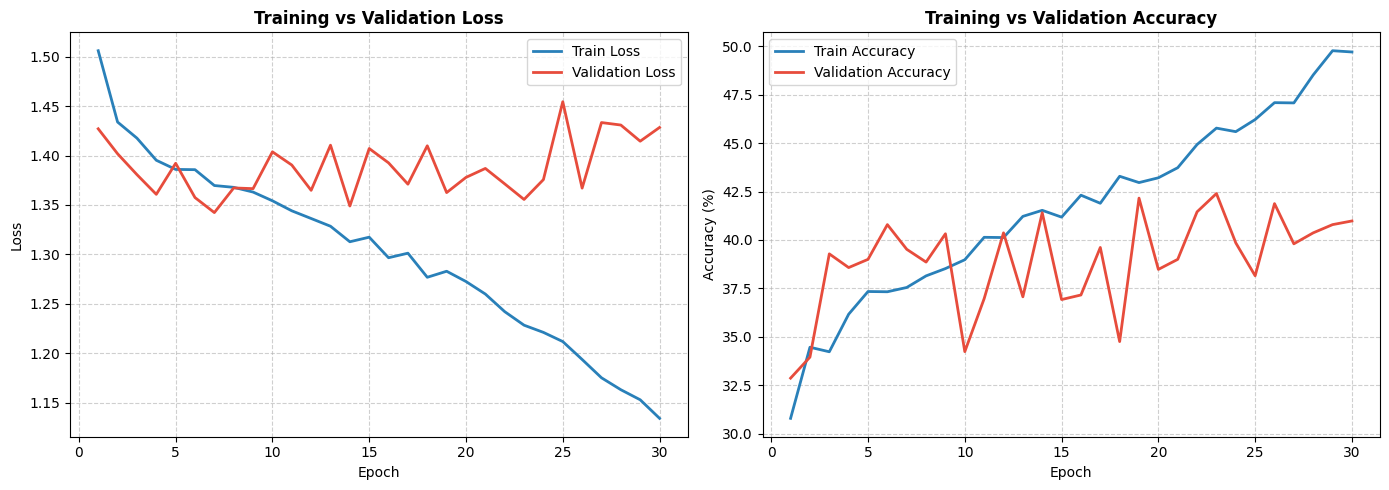

📌 Lowest Validation Loss was at Epoch 7.
⚠️ Overfitting likely! The model started memorizing the training data after epoch 7.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
axes[0].plot(range(1, EPOCHS+1), train_losses, label='Train Loss', color='#2980b9', linewidth=2)
axes[0].plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', color='#e74c3c', linewidth=2)
axes[0].set_title('Training vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot Accuracy
axes[1].plot(range(1, EPOCHS+1), train_accs, label='Train Accuracy', color='#2980b9', linewidth=2)
axes[1].plot(range(1, EPOCHS+1), val_accs, label='Validation Accuracy', color='#e74c3c', linewidth=2)
axes[1].set_title('Training vs Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Check for overfitting
best_val_epoch = np.argmin(val_losses) + 1
print(f"📌 Lowest Validation Loss was at Epoch {best_val_epoch}.")
if best_val_epoch < EPOCHS - 5:
    print(f"⚠️ Overfitting likely! The model started memorizing the training data after epoch {best_val_epoch}.")
else:
    print("✅ Model looks relatively healthy, overfitting is minimal.")


## 5. Final Evaluation & Confusion Matrix

Final Test Accuracy: 40.98%

Classification Report:
              precision    recall  f1-score   support

       Angry       0.54      0.36      0.43       197
       Happy       0.49      0.35      0.41       613
         Sad       0.61      0.28      0.38       311
     Neutral       0.35      0.09      0.14       386
  Frustrated       0.35      0.75      0.48       611

    accuracy                           0.41      2118
   macro avg       0.47      0.37      0.37      2118
weighted avg       0.45      0.41      0.38      2118



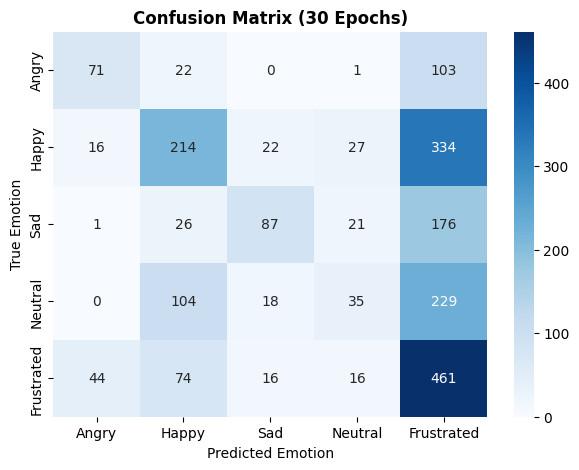

In [6]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Final Test Accuracy: {accuracy_score(all_labels, all_preds)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix (30 Epochs)", fontweight="bold")
plt.ylabel('True Emotion'); plt.xlabel('Predicted Emotion')
plt.show()
